## Эксперемент 1. Бейслайн

In [ ]:
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.utils as vutils
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import CelebA
import matplotlib.pyplot as plt
from IPython.display import HTML
import matplotlib.animation as animation


Шаг 2. Глобальные параметры

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!unzip -uq "/content/drive/MyDrive/Colab Notebooks/img_align_celeba.zip" -d "/content/drive/MyDrive/Colab Notebooks/"


In [ ]:
import gdown

url = "https://drive.google.com/uc?id=1m8-EBPgi5MRubrm6iQjafK2QMHDBMSfJ"
output = "./celeba.zip"

gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1m8-EBPgi5MRubrm6iQjafK2QMHDBMSfJ
From (redirected): https://drive.google.com/uc?id=1m8-EBPgi5MRubrm6iQjafK2QMHDBMSfJ&confirm=t&uuid=18b56771-62a1-46b7-abe3-4b55c01103dd
To: /content/celeba.zip
100%|██████████| 1.31G/1.31G [00:15<00:00, 86.4MB/s]


'./celeba.zip'

In [ ]:
import zipfile

with zipfile.ZipFile("./celeba.zip", "r") as zip_ref:
    zip_ref.extractall("./")

with zipfile.ZipFile("./celeba/img_align_celeba.zip", "r") as zip_ref:
    zip_ref.extractall("./celeba")


In [ ]:
import torchvision

image_path = './'
celeba_train_dataset = torchvision.datasets.CelebA(image_path, split='train', target_type='attr', download=False)
celeba_valid_dataset = torchvision.datasets.CelebA(image_path, split='valid', target_type='attr', download=False)
celeba_test_dataset = torchvision.datasets.CelebA(image_path, split='test', target_type='attr', download=False)

print('Train set:', len(celeba_train_dataset))
print('Validation set:', len(celeba_valid_dataset))
print('Test set:', len(celeba_test_dataset))

Train set: 162770
Validation set: 19867
Test set: 19962


In [ ]:
manualSeed = 42
random.seed(manualSeed)
torch.manual_seed(manualSeed)

dataroot = "/content/drive/MyDrive/Colab Notebooks/"
image_size = 128
nc = 3
nz = 100
ngf = 64
ndf = 64
batch_size = 64
num_epochs = 5
lr = 0.0002
beta1 = 0.5

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


Шаг 3. Загрузка датасета CelebA

In [ ]:
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    # transforms.Normalize((0.5,), (0.5,))
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) #rgb
])

dataset = CelebA(
    root=dataroot,
    split="train",
    target_type="attr",
    transform=transform,
    download=False
)

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)


Шаг 4. Инициализация весов

In [ ]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


Шаг 5. CSPUp Block

In [ ]:
class CSPUPBlock(nn.Module):
    def __init__(self, ngf):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(ngf, ngf, kernel_size=1),
            nn.BatchNorm2d(ngf),
            nn.ReLU(),
            nn.ConvTranspose2d(ngf, ngf, 2, 2),
            nn.Conv2d(ngf, ngf, 3, padding=1),
            nn.BatchNorm2d(ngf),
            nn.ReLU(),
            nn.Conv2d(ngf, ngf, 3, padding=1),
        )
        self.deconv = nn.ConvTranspose2d(ngf, ngf, 2, 2)

    def forward(self, x):
        x0, x1 = torch.chunk(x, 2, dim=1)
        return self.deconv(x0) + self.main(x1)


Шаг 6. Генератор с CSPUp

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.initial = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf*16, 4, 1, 0),
            nn.BatchNorm2d(ngf*16),
            nn.ReLU()
        )
        self.csp_blocks = nn.Sequential(
            CSPUPBlock(ngf*8),
            CSPUPBlock(ngf*4),
            CSPUPBlock(ngf*2),
            CSPUPBlock(ngf)
        )
        self.to_img = nn.Sequential(
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.initial(z)
        x = self.csp_blocks(x)
        return self.to_img(x)


Шаг 7. Дискриминатор

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.main = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1),              # 128 -> 64
            nn.LeakyReLU(0.2),
            nn.Conv2d(ndf, ndf*2, 4, 2, 1),           # 64 -> 32
            nn.BatchNorm2d(ndf*2),
            nn.LeakyReLU(0.2),
            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1),         # 32 -> 16
            nn.BatchNorm2d(ndf*4),
            nn.LeakyReLU(0.2),
            nn.Conv2d(ndf*4, ndf*8, 4, 2, 1),         # 16 -> 8
            nn.BatchNorm2d(ndf*8),
            nn.LeakyReLU(0.2),
            nn.Conv2d(ndf*8, 1, kernel_size=8, stride=1, padding=0),  # 8 -> 1
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.main(x)


Шаг 8. Обучение GAN

In [ ]:
netG = Generator().to(device)
netG.apply(weights_init)

print("Fake image shape from Generator:", netG(torch.randn(1, nz, 1, 1, device=device)).shape)


netD = Discriminator().to(device)
netD.apply(weights_init)

criterion = nn.BCELoss()
fixed_noise = torch.randn(64, nz, 1, 1, device=device)
real_label = 1.
fake_label = 0.

optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

img_list, G_losses, D_losses = [], [], []

for epoch in range(num_epochs):
    for i, data in enumerate(dataloader):
        netD.zero_grad()
        real = data[0].to(device)
        b_size = real.size(0)
        label = torch.full((b_size,), real_label, device=device)
        output = netD(real).view(-1)
        errD_real = criterion(output, label)
        errD_real.backward()
        D_x = output.mean().item()

        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(fake_label)
        output = netD(fake.detach()).view(-1)
        errD_fake = criterion(output, label)
        errD_fake.backward()
        errD = errD_real + errD_fake
        optimizerD.step()

        netG.zero_grad()
        label.fill_(real_label)
        output = netD(fake).view(-1)
        errG = criterion(output, label)
        errG.backward()
        optimizerG.step()

        if i % 100 == 0:
            print(f"[{epoch}/{num_epochs}][{i}/{len(dataloader)}] Loss_D: {errD.item():.4f} Loss_G: {errG.item():.4f}")

        G_losses.append(errG.item())
        D_losses.append(errD.item())

        if (i % 500 == 0) or ((epoch == num_epochs - 1) and (i == len(dataloader) - 1)):
            with torch.no_grad():
                fake = netG(fixed_noise).detach().cpu()
            img_list.append(vutils.make_grid(fake, padding=2, normalize=True))


Fake image shape from Generator: torch.Size([1, 3, 128, 128])
[0/5][0/2544] Loss_D: 2.1635 Loss_G: 21.9213
[0/5][100/2544] Loss_D: 0.0002 Loss_G: 49.9833
[0/5][200/2544] Loss_D: 0.0000 Loss_G: 48.9927
[0/5][300/2544] Loss_D: 0.0000 Loss_G: 49.0877
[0/5][400/2544] Loss_D: 0.0000 Loss_G: 48.3417
[0/5][500/2544] Loss_D: 0.0000 Loss_G: 47.9060
[0/5][600/2544] Loss_D: 0.0000 Loss_G: 47.6230
[0/5][700/2544] Loss_D: 0.0000 Loss_G: 48.0374
[0/5][800/2544] Loss_D: 0.0000 Loss_G: 47.9302
[0/5][900/2544] Loss_D: 0.0000 Loss_G: 47.8557
[0/5][1000/2544] Loss_D: 0.0000 Loss_G: 47.8052
[0/5][1100/2544] Loss_D: 0.0000 Loss_G: 47.7485
[0/5][1200/2544] Loss_D: 0.0000 Loss_G: 47.9391
[0/5][1300/2544] Loss_D: 0.0000 Loss_G: 47.6646
[0/5][1400/2544] Loss_D: 0.0000 Loss_G: 48.0265
[0/5][1500/2544] Loss_D: 0.0000 Loss_G: 47.4475
[0/5][1600/2544] Loss_D: 0.0000 Loss_G: 47.6728
[0/5][1700/2544] Loss_D: 0.0000 Loss_G: 47.7405
[0/5][1800/2544] Loss_D: 0.0000 Loss_G: 47.6425
[0/5][1900/2544] Loss_D: 0.0000 Loss_G

Шаг 9. Визуализация результатов

In [ ]:
import numpy as np

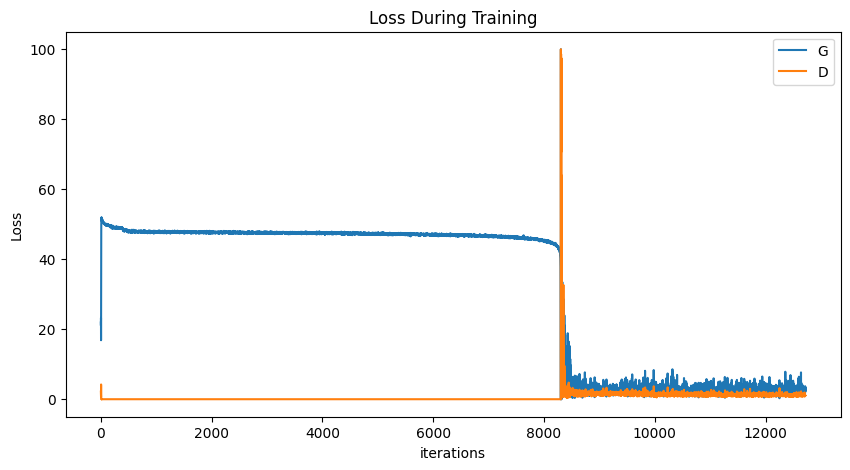

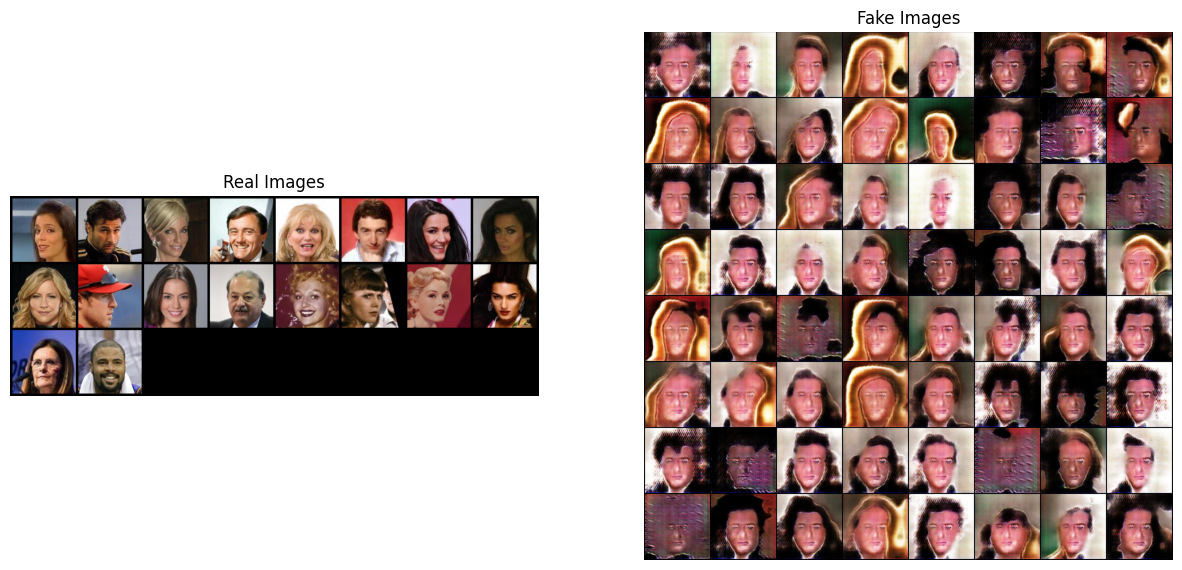

In [ ]:
plt.figure(figsize=(10,5))
plt.title("Loss During Training")
plt.plot(G_losses, label="G")
plt.plot(D_losses, label="D")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(15,15))
plt.subplot(1,2,1)
plt.axis("off")
plt.title("Real Images")
plt.imshow(np.transpose(vutils.make_grid(real[:64], padding=5, normalize=True).cpu(),(1,2,0)))

plt.subplot(1,2,2)
plt.axis("off")
plt.title("Fake Images")
plt.imshow(np.transpose(img_list[-1],(1,2,0)))
plt.show()


прогоним еще 5 эпох

In [ ]:
for epoch in range(num_epochs):
    for i, data in enumerate(dataloader):
        netD.zero_grad()
        real = data[0].to(device)
        b_size = real.size(0)
        label = torch.full((b_size,), real_label, device=device)
        output = netD(real).view(-1)
        errD_real = criterion(output, label)
        errD_real.backward()
        D_x = output.mean().item()

        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(fake_label)
        output = netD(fake.detach()).view(-1)
        errD_fake = criterion(output, label)
        errD_fake.backward()
        errD = errD_real + errD_fake
        optimizerD.step()

        netG.zero_grad()
        label.fill_(real_label)
        output = netD(fake).view(-1)
        errG = criterion(output, label)
        errG.backward()
        optimizerG.step()

        if i % 100 == 0:
            print(f"[{epoch}/{num_epochs}][{i}/{len(dataloader)}] Loss_D: {errD.item():.4f} Loss_G: {errG.item():.4f}")

        G_losses.append(errG.item())
        D_losses.append(errD.item())

        if (i % 500 == 0) or ((epoch == num_epochs - 1) and (i == len(dataloader) - 1)):
            with torch.no_grad():
                fake = netG(fixed_noise).detach().cpu()
            img_list.append(vutils.make_grid(fake, padding=2, normalize=True))

[0/5][0/2544] Loss_D: 1.1308 Loss_G: 4.7400
[0/5][100/2544] Loss_D: 0.8632 Loss_G: 3.0718
[0/5][200/2544] Loss_D: 0.9826 Loss_G: 3.8848
[0/5][300/2544] Loss_D: 1.0868 Loss_G: 1.7166
[0/5][400/2544] Loss_D: 1.6939 Loss_G: 3.3873
[0/5][500/2544] Loss_D: 1.0325 Loss_G: 2.1601
[0/5][600/2544] Loss_D: 1.1727 Loss_G: 3.2955
[0/5][700/2544] Loss_D: 1.0454 Loss_G: 5.8730
[0/5][800/2544] Loss_D: 0.9225 Loss_G: 2.4663
[0/5][900/2544] Loss_D: 0.6736 Loss_G: 2.4810
[0/5][1000/2544] Loss_D: 1.0235 Loss_G: 2.6070
[0/5][1100/2544] Loss_D: 0.7361 Loss_G: 3.4249
[0/5][1200/2544] Loss_D: 1.0011 Loss_G: 3.7280
[0/5][1300/2544] Loss_D: 1.3436 Loss_G: 1.6737
[0/5][1400/2544] Loss_D: 0.8404 Loss_G: 2.1177
[0/5][1500/2544] Loss_D: 1.1198 Loss_G: 2.5211
[0/5][1600/2544] Loss_D: 1.3172 Loss_G: 4.3720
[0/5][1700/2544] Loss_D: 0.8945 Loss_G: 3.5928
[0/5][1800/2544] Loss_D: 1.2589 Loss_G: 2.6473
[0/5][1900/2544] Loss_D: 1.1084 Loss_G: 4.3685
[0/5][2000/2544] Loss_D: 1.3121 Loss_G: 3.6773
[0/5][2100/2544] Loss_D: 

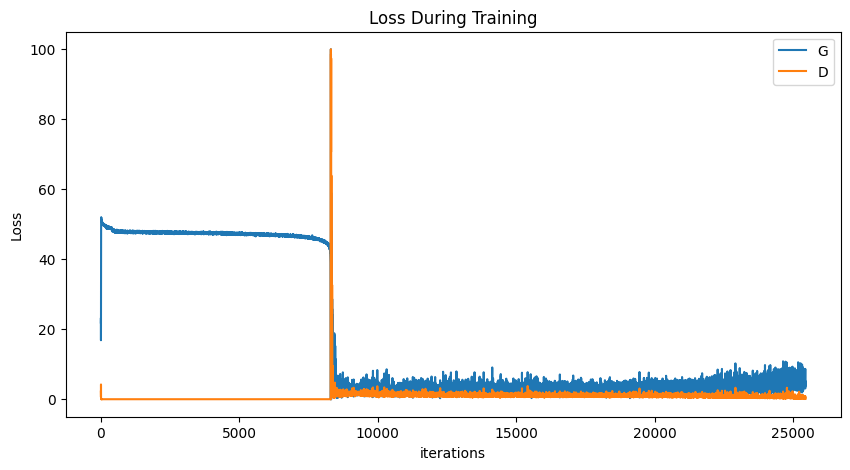

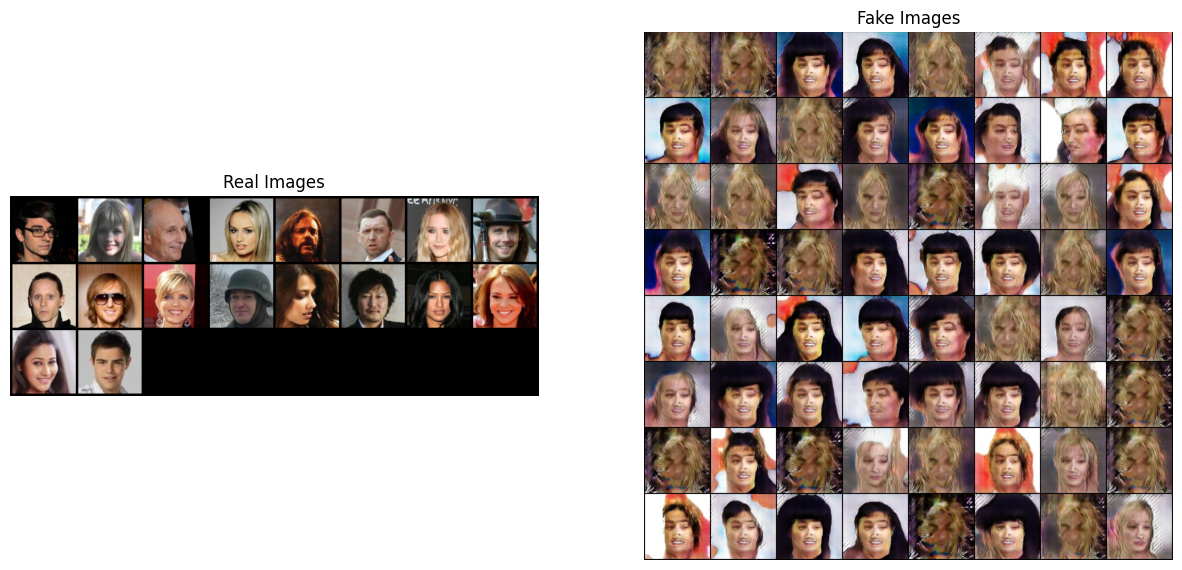

In [ ]:
plt.figure(figsize=(10,5))
plt.title("Loss During Training")
plt.plot(G_losses, label="G")
plt.plot(D_losses, label="D")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(15,15))
plt.subplot(1,2,1)
plt.axis("off")
plt.title("Real Images")
plt.imshow(np.transpose(vutils.make_grid(real[:64], padding=5, normalize=True).cpu(),(1,2,0)))

plt.subplot(1,2,2)
plt.axis("off")
plt.title("Fake Images")
plt.imshow(np.transpose(img_list[-1],(1,2,0)))
plt.show()


### Результаты
*   GAN не сошелся идеально, но есть положительная динамика.

*   Лица распознаваемые, генератор уловил основные черты (формы головы, глаз, волос).

*   Видны следы mode collapse (повторяющиеся лица).

*   Лоссы выглядят реалистично: изначально D слишком силен, потом G подтягивается.

### Итог по первому эксперименту:

*   CSPUp реализован корректно;

*   Архитектура генератора соблюдена;

*   GAN обучен и работает;



## Результаты реалистичны для первого запуска.
(*Добиться сходимости (регуляризации, изменение архитектуры, фишки с train loop)*)

Можно переходить к следующему эксперименту: модификация генератора и стабилизация обучения (например, с помощью label smoothing, понижения lr у D, gradient penalty и т.д.)